# CYBER 207 · Security Feature Engineering

## From raw network events to defensible model evidence

**Decision:** Which completed network events should enter a limited analyst-review queue?

**Prediction time:** When the event closes. **Unit:** One network event. **Target:** Synthetic suspicious activity.

By the end, you will be able to:
- turn raw telemetry into numeric, categorical, temporal, and behavioral features;
- keep every feature point-in-time correct;
- fit preprocessing on training data only;
- compare raw and engineered models without changing the evaluation setup;
- test feature code for missing, unknown, and extreme inputs.

> All data are synthetic and local. A model score prioritizes review; it is not proof of malicious behavior.

In [1]:
import ipaddress
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

SEED = 207
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

---
## 1 · Create synthetic security telemetry

The raw table mixes identifiers, timestamps, categories, counts, continuous measurements, missing values, and a label. That does **not** mean every column belongs in a model.

Before running the next cell, predict:
1. Which columns are identifiers rather than reusable evidence?
2. Which fields are strongly skewed?
3. What could missing `duration_seconds` mean?

In [2]:
n_events = 1_200
event_time = pd.date_range("2025-01-01", periods=n_events, freq="15min")
source_pool = [f"10.0.{subnet}.{host}" for subnet in range(4) for host in range(1, 21)]
destination_pool = [f"172.16.1.{host}" for host in range(1, 21)] + [f"203.0.113.{host}" for host in range(1, 11)]
ports = rng.choice([22, 53, 80, 443, 445, 3389, 8080, 49152], n_events, p=[.06, .10, .19, .36, .07, .05, .10, .07])
protocol = np.where(ports == 53, "UDP", rng.choice(["TCP", "TCP", "TCP", "ICMP"], n_events))
bytes_out = np.maximum(0, rng.lognormal(8.2, 1.35, n_events).astype(int))
bytes_in = np.maximum(0, rng.lognormal(8.5, 1.1, n_events).astype(int))
duration = rng.gamma(2.0, 18.0, n_events)
packets = np.maximum(1, (bytes_in + bytes_out) // rng.integers(450, 1300, n_events))
failed_logins = rng.poisson(0.35, n_events)

raw = pd.DataFrame({
    "event_id": [f"evt-{i:05d}" for i in range(n_events)],
    "event_time": event_time,
    "source_ip": rng.choice(source_pool, n_events),
    "destination_ip": rng.choice(destination_pool, n_events),
    "destination_port": ports,
    "protocol": protocol,
    "service": np.select(
        [ports == 22, ports == 53, ports == 80, ports == 443, ports == 445, ports == 3389],
        ["ssh", "dns", "http", "https", "smb", "rdp"],
        default="other",
    ),
    "bytes_in": bytes_in,
    "bytes_out": bytes_out,
    "duration_seconds": duration,
    "packet_count": packets,
    "failed_logins": failed_logins,
})

# Missing duration is more common for UDP telemetry; a realistic collection artifact.
missing_probability = np.where(raw["protocol"].eq("UDP"), 0.22, 0.04)
raw.loc[rng.random(n_events) < missing_probability, "duration_seconds"] = np.nan
raw.loc[rng.choice(n_events, 8, replace=False), "bytes_out"] *= 80

hour = raw["event_time"].dt.hour
risk = (
    1.1 * raw["failed_logins"]
    + 1.2 * raw["destination_port"].isin([22, 445, 3389])
    + 1.0 * ((hour < 6) | (hour >= 22))
    + 0.7 * (raw["bytes_out"] > raw["bytes_out"].quantile(.92))
    + rng.normal(0, 1.1, n_events)
)
raw["suspicious"] = (risk > np.quantile(risk, .86)).astype(int)
raw["investigation_result"] = np.where(raw["suspicious"].eq(1), "confirmed", "closed_benign")
raw.head()

,event_id,event_time,source_ip,destination_ip,destination_port,protocol,service,bytes_in,bytes_out,duration_seconds,packet_count,failed_logins,suspicious,investigation_result
0,evt-00000,2025-01-01 00:00:00,10.0.2.14,172.16.1.19,80,TCP,http,12546,1193,NaN,13,0,0,closed_benign
1,evt-00001,2025-01-01 00:15:00,10.0.2.13,172.16.1.10,443,TCP,https,5779,1075,17.315693,13,0,0,closed_benign
2,evt-00002,2025-01-01 00:30:00,10.0.0.14,172.16.1.6,8080,TCP,other,1874,1915,26.359362,5,0,0,closed_benign
3,evt-00003,2025-01-01 00:45:00,10.0.3.15,172.16.1.14,443,TCP,https,3700,3300,49.894549,6,0,0,closed_benign
4,evt-00004,2025-01-01 01:00:00,10.0.2.2,203.0.113.4,3389,TCP,rdp,15771,487,15.417551,16,0,0,closed_benign


---
## 2 · Inspect schema, quality, and the target

Feature engineering starts with measurement questions, not transformer APIs.

- `event_id`: useful for tracing, dangerous as a memorization feature.
- `event_time`: contains context, but raw datetimes need a representation.
- `source_ip`: an entity with network structure, not an ordinary number.
- `investigation_result`: created after review, so it leaks the target.

**Teaching pause:** Is a missing value equivalent to zero? Is a duplicate always invalid?

,dtype,missing,unique
event_id,str,0,1200
event_time,datetime64[us],0,1200
source_ip,str,0,80
destination_ip,str,0,30
destination_port,int64,0,8
protocol,str,0,3
service,str,0,7
bytes_in,int64,0,1148
bytes_out,int64,0,1131
duration_seconds,float64,70,1130


Shape: (1200, 14) | duplicate rows: 0

Class balance:


,fraction
suspicious,
0,0.86
1,0.14


,count,mean,std,min,25%,50%,75%,max
bytes_in,1200.0,8799.083333,13621.868419,118.000000,2280.50000,4516.500000,9989.250000,2.043970e+05
bytes_out,1200.0,13155.200833,81900.167943,29.000000,1443.25000,3484.500000,9056.250000,2.384640e+06
duration_seconds,1130.0,36.056829,26.345913,0.900218,16.72876,29.354692,48.564992,1.840186e+02
packet_count,1200.0,22.317500,32.644725,1.000000,6.00000,13.000000,25.000000,5.060000e+02
failed_logins,1200.0,0.363333,0.606874,0.000000,0.00000,0.000000,1.000000,5.000000e+00


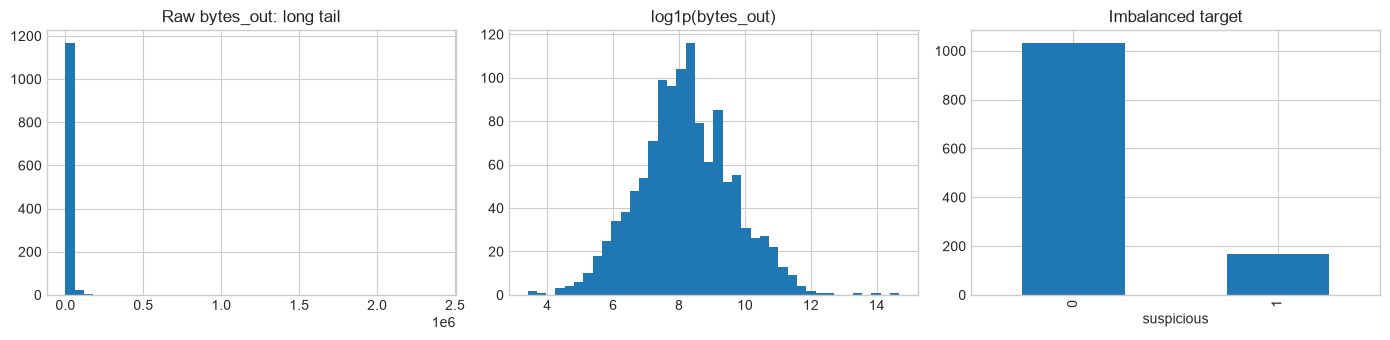

In [3]:
quality_report = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique": raw.nunique(),
})
display(quality_report)
print(f"Shape: {raw.shape} | duplicate rows: {raw.duplicated().sum()}")
print("\nClass balance:")
display(raw["suspicious"].value_counts(normalize=True).rename("fraction").to_frame())
display(raw[["bytes_in", "bytes_out", "duration_seconds", "packet_count", "failed_logins"]].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(raw["bytes_out"], bins=40); axes[0].set_title("Raw bytes_out: long tail")
axes[1].hist(np.log1p(raw["bytes_out"]), bins=40); axes[1].set_title("log1p(bytes_out)")
raw["suspicious"].value_counts().sort_index().plot.bar(ax=axes[2]); axes[2].set_title("Imbalanced target")
plt.tight_layout()

---
## 3 · Engineer features with explicit meaning

This transformation creates four families:

| Family | Examples | Question answered |
|---|---|---|
| Time | hour, weekend, cyclic hour | When did it happen? |
| Network | private IP, subnet match, port class | Where and through which service? |
| Rate | bytes/sec, packets/sec, byte ratio | How intense was the event? |
| History | prior source events/failures in 1 hour | Is this unusual recent behavior? |

Rolling history must exclude the current row and all future rows. Safe division must turn zero denominators into a documented value rather than infinity.

In [4]:
def safe_divide(numerator, denominator):
    denominator = pd.Series(denominator, index=numerator.index).replace(0, np.nan)
    return numerator.div(denominator).replace([np.inf, -np.inf], np.nan).fillna(0.0)


def point_in_time_counts(frame, window="1h"):
    """Count earlier source events and failures in a trailing window."""
    window_delta = pd.Timedelta(window)
    event_queues = defaultdict(deque)
    failure_queues = defaultdict(deque)
    prior_events, prior_failures = [], []

    for row in frame.sort_values("event_time").itertuples():
        source_events = event_queues[row.source_ip]
        source_failures = failure_queues[row.source_ip]
        boundary = row.event_time - window_delta
        while source_events and source_events[0] <= boundary:
            source_events.popleft()
        while source_failures and source_failures[0] <= boundary:
            source_failures.popleft()
        prior_events.append((row.Index, len(source_events)))
        prior_failures.append((row.Index, len(source_failures)))
        source_events.append(row.event_time)
        if row.failed_logins > 0:
            source_failures.extend([row.event_time] * int(row.failed_logins))

    return (
        pd.Series(dict(prior_events), name="source_events_prior_1h"),
        pd.Series(dict(prior_failures), name="source_failures_prior_1h"),
    )


def engineer_features(frame):
    features = frame.copy()
    timestamp = pd.to_datetime(features["event_time"])
    features["hour"] = timestamp.dt.hour
    features["weekday"] = timestamp.dt.dayofweek
    features["is_weekend"] = features["weekday"].ge(5).astype(int)
    features["is_after_hours"] = ((features["hour"] < 6) | (features["hour"] >= 22)).astype(int)
    features["hour_sin"] = np.sin(2 * np.pi * features["hour"] / 24)
    features["hour_cos"] = np.cos(2 * np.pi * features["hour"] / 24)
    features["log_bytes_out"] = np.log1p(features["bytes_out"].clip(lower=0))
    features["source_private"] = features["source_ip"].map(lambda value: int(ipaddress.ip_address(value).is_private))
    features["destination_private"] = features["destination_ip"].map(lambda value: int(ipaddress.ip_address(value).is_private))
    features["source_subnet"] = features["source_ip"].str.rsplit(".", n=1).str[0]
    features["destination_subnet"] = features["destination_ip"].str.rsplit(".", n=1).str[0]
    features["same_subnet"] = features["source_subnet"].eq(features["destination_subnet"]).astype(int)
    features["privileged_port"] = features["destination_port"].lt(1024).astype(int)
    features["port_category"] = np.select(
        [features["destination_port"].isin([22, 3389]), features["destination_port"].isin([80, 443, 8080]), features["destination_port"].eq(53)],
        ["remote_access", "web", "dns"],
        default="other",
    )
    features["bytes_per_second"] = safe_divide(features["bytes_in"] + features["bytes_out"], features["duration_seconds"])
    features["packets_per_second"] = safe_divide(features["packet_count"], features["duration_seconds"])
    features["outbound_inbound_ratio"] = safe_divide(features["bytes_out"], features["bytes_in"])
    prior_events, prior_failures = point_in_time_counts(features)
    features[prior_events.name] = prior_events
    features[prior_failures.name] = prior_failures
    return features

engineered = engineer_features(raw)
engineered[["event_time", "source_ip", "source_events_prior_1h", "source_failures_prior_1h", "bytes_per_second"]].head(10)

,event_time,source_ip,source_events_prior_1h,source_failures_prior_1h,bytes_per_second
0,2025-01-01 00:00:00,10.0.2.14,0,0,0.000000
1,2025-01-01 00:15:00,10.0.2.13,0,0,395.825919
2,2025-01-01 00:30:00,10.0.0.14,0,0,143.743996
3,2025-01-01 00:45:00,10.0.3.15,0,0,140.295887
4,2025-01-01 01:00:00,10.0.2.2,0,0,1054.512472
5,2025-01-01 01:15:00,10.0.0.1,0,0,108.874576
6,2025-01-01 01:30:00,10.0.2.12,0,0,346.770277
7,2025-01-01 01:45:00,10.0.1.18,0,0,543.438907
8,2025-01-01 02:00:00,10.0.1.12,0,0,5206.075797
9,2025-01-01 02:15:00,10.0.2.3,0,0,151.986779


---
## 4 · Learn transformations from training data

`fit` learns state; `transform` applies frozen state.

- Median imputation learns a training median.
- Missing indicators preserve the fact that collection failed.
- One-hot encoding learns category names and column order.
- Scaling learns center and spread.

Arbitrary labels such as `TCP=1, UDP=2, ICMP=3` invent order and distance. One-hot encoding makes no such claim. Standard scaling is sensitive to extreme values; robust scaling uses medians and quantiles.

In [5]:
demo_train = raw.iloc[:900]

imputer = SimpleImputer(strategy="median", add_indicator=True)
imputed = imputer.fit_transform(demo_train[["duration_seconds", "bytes_out"]])
print("Imputation output columns:", imputer.get_feature_names_out().tolist())
display(pd.DataFrame(imputed, columns=imputer.get_feature_names_out()).head())

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_train = encoder.fit_transform(demo_train[["protocol", "service"]])
unknown_example = pd.DataFrame({"protocol": ["QUIC"], "service": ["new_service"]})
print("Learned one-hot columns:", encoder.get_feature_names_out().tolist())
print("Unknown categories transform safely to:", encoder.transform(unknown_example).tolist())

scaling_sample = raw[["bytes_out", "duration_seconds"]].fillna(raw[["bytes_out", "duration_seconds"]].median())
scaling_comparison = pd.DataFrame({
    "raw_bytes": scaling_sample["bytes_out"],
    "standard_bytes": StandardScaler().fit_transform(scaling_sample)[..., 0],
    "robust_bytes": RobustScaler().fit_transform(scaling_sample)[..., 0],
})
display(scaling_comparison.loc[scaling_comparison["raw_bytes"].nlargest(5).index].sort_values("raw_bytes", ascending=False))

Imputation output columns: ['duration_seconds', 'bytes_out', 'missingindicator_duration_seconds']


,duration_seconds,bytes_out,missingindicator_duration_seconds
0,29.476239,1193.0,1.0
1,17.315693,1075.0,0.0
2,26.359362,1915.0,0.0
3,49.894549,3300.0,0.0
4,15.417551,487.0,0.0


Learned one-hot columns: ['protocol_ICMP', 'protocol_TCP', 'protocol_UDP', 'service_dns', 'service_http', 'service_https', 'service_other', 'service_rdp', 'service_smb', 'service_ssh']
Unknown categories transform safely to: [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]


,raw_bytes,standard_bytes,robust_bytes
995,2384640,28.967871,312.774924
1127,1233440,14.905874,161.559898
545,709360,8.504196,92.719756
408,261616,3.034968,33.906673
100,199520,2.276461,25.750099


---
## 5 · Remove identifiers and audit leakage

A valid feature passes this test:

> For this row, could we compute this exact value at prediction time using only information already available?

`event_id` invites memorization. `investigation_result` is created after the outcome and directly reveals the target. Neither belongs in the feature matrix.

We split chronologically: the first 75% trains the model; the final 25% simulates a future deployment period. The deliberately invalid comparison below shows why leakage is dangerous.

In [6]:
split_at = int(len(engineered) * .75)
train = engineered.iloc[:split_at].copy()
test = engineered.iloc[split_at:].copy()
y_train, y_test = train["suspicious"], test["suspicious"]

valid_small = ["failed_logins", "log_bytes_out", "is_after_hours", "privileged_port"]
leak_train = train[valid_small].assign(future_outcome_proxy=train["investigation_result"].eq("confirmed").astype(int))
leak_test = test[valid_small].assign(future_outcome_proxy=test["investigation_result"].eq("confirmed").astype(int))

valid_model = LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=SEED).fit(train[valid_small], y_train)
invalid_model = LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=SEED).fit(leak_train, y_train)
comparison = pd.Series({
    "valid point-in-time features": average_precision_score(y_test, valid_model.predict_proba(test[valid_small])[:, 1]),
    "INVALID: includes future outcome": average_precision_score(y_test, invalid_model.predict_proba(leak_test)[:, 1]),
}, name="test average precision")
display(comparison.to_frame())
print("The invalid score is not an achievement; it proves that the evaluation question was corrupted.")

,test average precision
valid point-in-time features,0.318449
INVALID: includes future outcome,1.000000


The invalid score is not an achievement; it proves that the evaluation question was corrupted.


---
## 6 · Build a leakage-safe pipeline

The pipeline fits imputation, scaling, category vocabulary, and the classifier on training rows only. Validation and test rows pass through frozen state.

**Numeric columns** receive median imputation, a missingness indicator, and robust scaling. **Categorical columns** receive most-frequent imputation and one-hot encoding with unknown-category support.

The model is intentionally simple. This lesson asks whether the evidence is trustworthy, not whether we can hide data problems behind model complexity.

In [7]:
numeric_features = [
    "bytes_in", "bytes_out", "duration_seconds", "packet_count", "failed_logins",
    "log_bytes_out", "hour_sin", "hour_cos", "is_weekend", "is_after_hours",
    "source_private", "destination_private", "same_subnet", "privileged_port",
    "bytes_per_second", "packets_per_second", "outbound_inbound_ratio",
    "source_events_prior_1h", "source_failures_prior_1h",
]
categorical_features = ["protocol", "service", "port_category", "source_subnet"]

numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", RobustScaler()),
])
categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])
engineered_model = Pipeline([
    ("prepare", preprocessor),
    ("model", LogisticRegression(max_iter=2_000, class_weight="balanced", random_state=SEED)),
])

engineered_model.fit(train, y_train)
test_probability = engineered_model.predict_proba(test)[:, 1]
print(f"Test average precision: {average_precision_score(y_test, test_probability):.3f}")
print(f"Test ROC-AUC:          {roc_auc_score(y_test, test_probability):.3f}")

feature_names = engineered_model.named_steps["prepare"].get_feature_names_out()
print(f"Transformed width: {len(feature_names)}")
print("First 20 output features:", feature_names[:20].tolist())

Test average precision: 0.381
Test ROC-AUC:          0.832
Transformed width: 38
First 20 output features: ['numeric__bytes_in', 'numeric__bytes_out', 'numeric__duration_seconds', 'numeric__packet_count', 'numeric__failed_logins', 'numeric__log_bytes_out', 'numeric__hour_sin', 'numeric__hour_cos', 'numeric__is_weekend', 'numeric__is_after_hours', 'numeric__source_private', 'numeric__destination_private', 'numeric__same_subnet', 'numeric__privileged_port', 'numeric__bytes_per_second', 'numeric__packets_per_second', 'numeric__outbound_inbound_ratio', 'numeric__source_events_prior_1h', 'numeric__source_failures_prior_1h', 'numeric__missingindicator_duration_seconds']


---
## 7 · Evaluate the decision, not only ranking

Average precision summarizes ranking under class imbalance. ROC-AUC is included for comparison, but can look generous when negatives dominate.

A threshold converts scores into queue decisions. Here `0.60` is a teaching policy, not an optimized universal value. Ask:
- How many suspicious events does the queue catch?
- How many routine events consume analyst time?
- What threshold can the team operationally support?

              precision    recall  f1-score   support

     routine      0.948     0.830     0.885       264
      review      0.348     0.667     0.457        36

    accuracy                          0.810       300
   macro avg      0.648     0.748     0.671       300
weighted avg      0.876     0.810     0.834       300



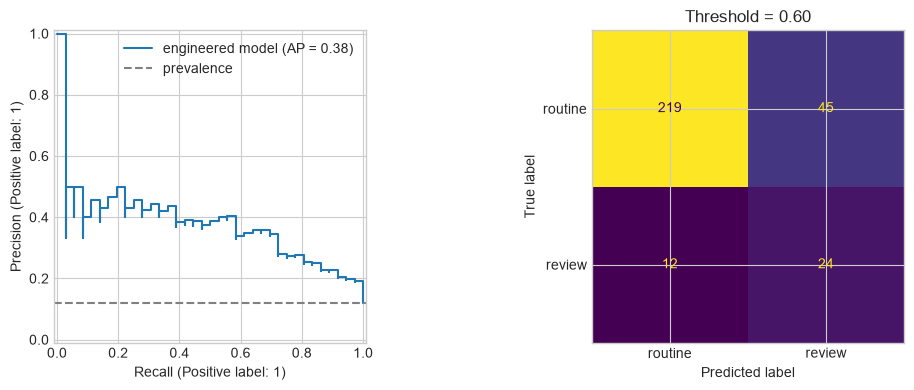

In [8]:
threshold = 0.60
test_prediction = (test_probability >= threshold).astype(int)
print(classification_report(y_test, test_prediction, target_names=["routine", "review"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[0], name="engineered model")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="prevalence")
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, ax=axes[1], display_labels=["routine", "review"], colorbar=False)
axes[1].set_title(f"Threshold = {threshold:.2f}")
plt.tight_layout()

---
## 8 · Compare raw and engineered evidence

Hold the classifier, chronological folds, and metric constant. Change only the feature set.

This is an **ablation-style comparison**, not proof that any feature causes suspicious activity. Correlated features can substitute for each other, and results depend on the data-generating process.

We report fold values as well as the mean so one unusually easy period cannot hide instability.

In [9]:
raw_numeric = ["bytes_in", "bytes_out", "duration_seconds", "packet_count", "failed_logins", "destination_port"]
raw_categorical = ["protocol", "service"]
raw_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, raw_numeric),
    ("categorical", categorical_pipeline, raw_categorical),
])
raw_model = Pipeline([
    ("prepare", raw_preprocessor),
    ("model", LogisticRegression(max_iter=2_000, class_weight="balanced", random_state=SEED)),
])

time_cv = TimeSeriesSplit(n_splits=4)
scoring = {"ap": "average_precision", "roc_auc": "roc_auc", "precision": "precision", "recall": "recall", "f1": "f1"}
rows = []
for name, candidate in {"raw": raw_model, "engineered": engineered_model}.items():
    scores = cross_validate(candidate, engineered, engineered["suspicious"], cv=time_cv, scoring=scoring)
    row = {"feature_set": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_folds"] = np.round(values, 3).tolist()
    rows.append(row)
comparison_cv = pd.DataFrame(rows).set_index("feature_set")
display(comparison_cv)

,ap_mean,ap_folds,roc_auc_mean,roc_auc_folds,precision_mean,precision_folds,recall_mean,recall_folds,f1_mean,f1_folds
feature_set,,,,,,,,,,
raw,0.482548,"[0.37, 0.403, 0.65, 0.508]",0.803993,"[0.724, 0.807, 0.893, 0.791]",0.316123,"[0.317, 0.357, 0.312, 0.278]",0.778646,"[0.667, 0.781, 0.909, 0.758]",0.447892,"[0.43, 0.49, 0.465, 0.407]"
engineered,0.471740,"[0.403, 0.456, 0.63, 0.398]",0.826979,"[0.743, 0.841, 0.901, 0.823]",0.381007,"[0.358, 0.391, 0.446, 0.329]",0.720371,"[0.615, 0.781, 0.758, 0.727]",0.497073,"[0.453, 0.521, 0.562, 0.453]"


---
## 9 · Select features using multiple kinds of evidence

Selection is a deployment decision, not a leaderboard ritual.

- **Variance:** constant columns carry no separating information.
- **Correlation:** highlights redundant linear relationships, not all redundancy.
- **Mutual information:** detects broader dependency, but estimates can be noisy.
- **Permutation importance:** measures score loss when a fitted model loses one column's information.

None proves causation. Also consider latency, availability, drift, privacy, abuse resistance, and ownership.

,variance,mutual_information
failed_logins,3.896614e-01,0.068307
log_bytes_out,2.028782e+00,0.030251
is_after_hours,2.267408e-01,0.020833
privileged_port,1.882635e-01,0.000000
bytes_per_second,8.670763e+06,0.000000
source_failures_prior_1h,1.984427e-02,0.000000


Pairwise correlation (inspect large absolute values for redundancy):


,failed_logins,log_bytes_out,is_after_hours,privileged_port,bytes_per_second,source_failures_prior_1h
failed_logins,1.00,0.04,0.03,-0.00,0.05,-0.01
log_bytes_out,0.04,1.00,0.03,0.05,0.30,-0.06
is_after_hours,0.03,0.03,1.00,0.01,0.02,-0.05
privileged_port,-0.00,0.05,0.01,1.00,0.01,-0.05
bytes_per_second,0.05,0.30,0.02,0.01,1.00,-0.01
source_failures_prior_1h,-0.01,-0.06,-0.05,-0.05,-0.01,1.00


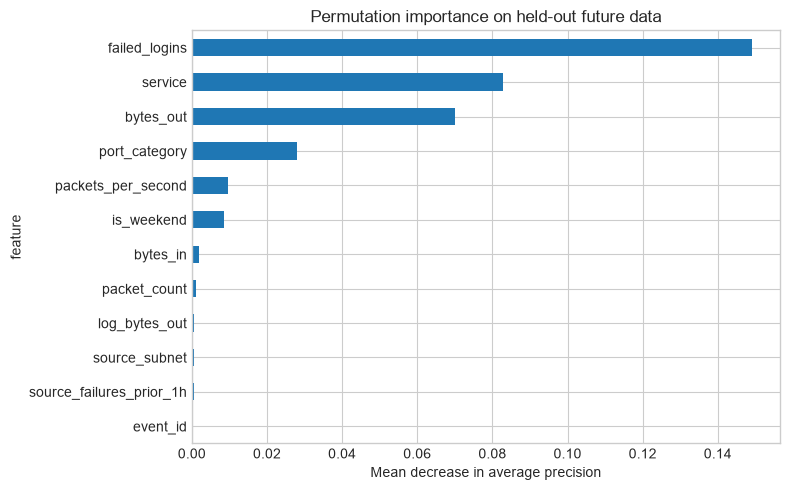

In [10]:
selection_columns = ["failed_logins", "log_bytes_out", "is_after_hours", "privileged_port", "bytes_per_second", "source_failures_prior_1h"]
selection_data = train[selection_columns].replace([np.inf, -np.inf], np.nan).fillna(train[selection_columns].median())

variance = selection_data.var().rename("variance")
mutual_information = pd.Series(
    mutual_info_classif(selection_data, y_train, random_state=SEED),
    index=selection_columns,
    name="mutual_information",
)
display(pd.concat([variance, mutual_information], axis=1).sort_values("mutual_information", ascending=False))
print("Pairwise correlation (inspect large absolute values for redundancy):")
display(selection_data.corr().round(2))

importance = permutation_importance(
    engineered_model, test, y_test, scoring="average_precision", n_repeats=10, random_state=SEED
)
importance_frame = pd.DataFrame({"feature": test.columns, "importance": importance.importances_mean})
importance_frame.nlargest(12, "importance").sort_values("importance").plot.barh(x="feature", y="importance", legend=False, figsize=(8, 5))
plt.title("Permutation importance on held-out future data")
plt.xlabel("Mean decrease in average precision")
plt.tight_layout()

---
## 10 · Test production-shaped surprises

Production will eventually send categories absent from training, missing measurements, and shifted distributions. A robust pipeline should define behavior rather than crash silently.

The next event uses unseen protocol/service/subnet values and a missing duration. Successful prediction proves compatibility, not correctness. Monitoring must still report category novelty, missingness changes, feature freshness, and score drift.

In [11]:
novel_event = test.iloc[[0]].copy()
novel_event.loc[:, "protocol"] = "QUIC"
novel_event.loc[:, "service"] = "experimental"
novel_event.loc[:, "port_category"] = "unseen_category"
novel_event.loc[:, "source_subnet"] = "198.51.100"
novel_event.loc[:, "duration_seconds"] = np.nan
novel_probability = engineered_model.predict_proba(novel_event)[:, 1]
print(f"Prediction succeeded for unseen categories and missing duration: {novel_probability[0]:.3f}")

monitor = pd.DataFrame({
    "train_missing_rate": train[numeric_features].isna().mean(),
    "test_missing_rate": test[numeric_features].isna().mean(),
})
monitor["absolute_change"] = (monitor["test_missing_rate"] - monitor["train_missing_rate"]).abs()
display(monitor.sort_values("absolute_change", ascending=False).head(8))

Prediction succeeded for unseen categories and missing duration: 0.268


,train_missing_rate,test_missing_rate,absolute_change
duration_seconds,0.058889,0.056667,0.002222
bytes_in,0.000000,0.000000,0.000000
bytes_out,0.000000,0.000000,0.000000
packet_count,0.000000,0.000000,0.000000
failed_logins,0.000000,0.000000,0.000000
log_bytes_out,0.000000,0.000000,0.000000
hour_sin,0.000000,0.000000,0.000000
hour_cos,0.000000,0.000000,0.000000


---
## 11 · Student feature-engineering exercise

Complete or change the marked rules, then explain each choice.

1. **Burst detection:** flag a source with at least `threshold` prior events in the trailing hour.
2. **Uncommon port:** define uncommon relative to the **training** frequency table, not the full dataset.
3. **Rolling failures:** reuse the point-in-time helper; do not include the current event.

Expected examples:
- prior counts `[0, 2, 5]` with threshold `5` → `[0, 0, 1]`
- ports `[443, 65000]` with common `{80, 443}` → `[0, 1]`

**Extension:** How would event-arrival delay change the rolling feature available online?

In [12]:
def burst_flag(prior_event_count, threshold=5):
    # TODO: Try thresholds that match different analyst capacities.
    return pd.Series(prior_event_count).ge(threshold).astype(int)


def fit_common_ports(training_ports, minimum_frequency=0.03):
    # This learned set must be fit on training rows only.
    frequency = pd.Series(training_ports).value_counts(normalize=True)
    return set(frequency[frequency >= minimum_frequency].index)


def uncommon_port_flag(ports_to_score, common_ports):
    # TODO: Decide how your system handles malformed or missing ports.
    return (~pd.Series(ports_to_score).isin(common_ports)).astype(int)


common_ports = fit_common_ports(train["destination_port"])
exercise_output = pd.DataFrame({
    "burst": burst_flag([0, 2, 5]),
    "uncommon_port": uncommon_port_flag([443, 65000, 80], common_ports),
})
display(exercise_output)
print("Training-derived common ports:", sorted(common_ports))

,burst,uncommon_port
0,0,0
1,0,1
2,1,0


Training-derived common ports: [22, 53, 80, 443, 445, 3389, 8080, 49152]


---
## 12 · Validate the feature contract

Feature code is production code. Tests should cover schema, determinism, missing values, zero denominators, unknown categories, time boundaries, and forbidden fields.

The checks below are deliberately readable. Add boundary tests for exactly one hour ago and for late-arriving events.

In [13]:
assert len(engineered) == len(raw)
assert engineered.index.equals(raw.index)
assert not np.isinf(engineered[["bytes_per_second", "packets_per_second", "outbound_inbound_ratio"]].to_numpy()).any()
assert engineer_features(raw).equals(engineered), "Feature transformation must be deterministic"
assert engineered_model.named_steps["prepare"].transform(test).shape[0] == len(test)
assert np.isfinite(novel_probability).all(), "Unknown categories and missing values must score safely"
assert "investigation_result" not in numeric_features + categorical_features
assert "event_id" not in numeric_features + categorical_features
assert burst_flag([0, 2, 5], threshold=5).tolist() == [0, 0, 1]
assert uncommon_port_flag([80, 65000], {80, 443}).tolist() == [0, 1]
assert safe_divide(pd.Series([10.0]), pd.Series([0.0])).iloc[0] == 0.0

mini = pd.DataFrame({
    "event_time": pd.to_datetime(["2025-01-01 09:00", "2025-01-01 09:30", "2025-01-01 10:05"]),
    "source_ip": ["10.0.0.1"] * 3,
    "failed_logins": [1, 0, 1],
})
mini_events, mini_failures = point_in_time_counts(mini)
assert mini_events.tolist() == [0, 1, 1]
assert mini_failures.tolist() == [0, 1, 0]
print("All feature-contract checks passed.")

All feature-contract checks passed.


---
## Exit ticket · Write one feature contract

Choose one feature from this notebook and record:

| Contract field | Your answer |
|---|---|
| Name and plain-English meaning | |
| Entity and unit of prediction | |
| Observation timestamp | |
| Window and boundary rule | |
| Source and owner | |
| Missing/unknown behavior | |
| Expected range and freshness | |
| Drift monitor | |
| Offline/online parity test | |

Then answer: **What decision value does this feature add, and what does it cost to operate?**

A useful feature is not merely predictive. It is available, reproducible, monitored, affordable, and appropriate for the decision.